# Day 2 — Exploratory Data Analysis (EDA)

Understanding the data before touching any models.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

df = pd.read_csv("train.tsv", delimiter='\t', header=None, names=['text', 'label'])
df['length'] = df['text'].apply(lambda x: len(x.split()))

print("Data loaded:", df.shape)
print(df.head(3))

Matplotlib is building the font cache; this may take a moment.


Data loaded: (6920, 3)
                                                text  label  length
0  a stirring , funny and finally transporting re...      1      18
1  apparently reassembled from the cutting room f...      0      12
2  they presume their audience wo n't sit still f...      0      36


/var/folders/xb/blk7kpmd3vj2lvy9kh5w4k_40000gn/T/ipykernel_61332/1672857501.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette=['#e74c3c', '#2ecc71'])


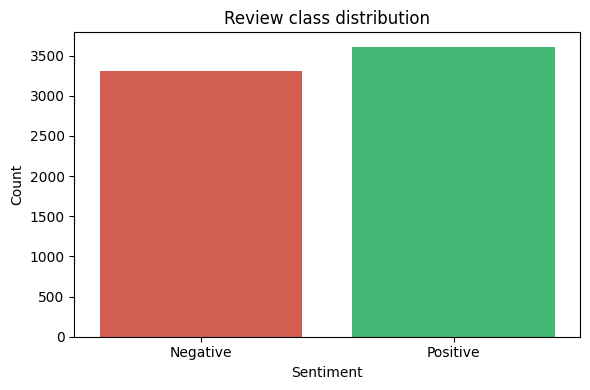

In [2]:
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df, palette=['#e74c3c', '#2ecc71'])
plt.xticks([0, 1], ['Negative', 'Positive'])
plt.title('Review class distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('chart_class_distribution.png', dpi=150)
plt.show()

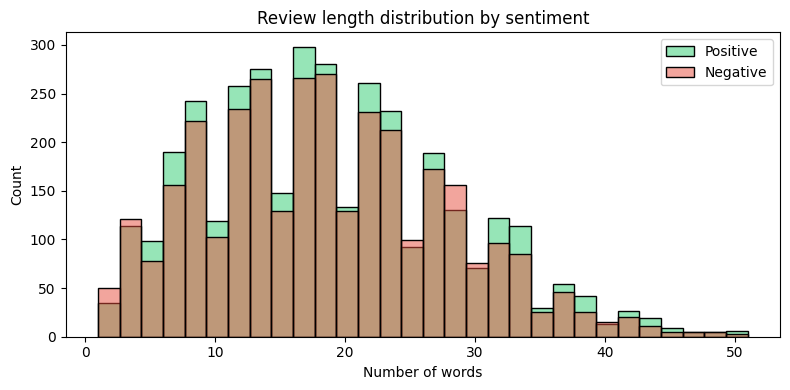

In [3]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='length', hue='label', bins=30, palette=['#e74c3c', '#2ecc71'])
plt.title('Review length distribution by sentiment')
plt.xlabel('Number of words')
plt.ylabel('Count')
plt.legend(labels=['Positive', 'Negative'])
plt.tight_layout()
plt.savefig('chart_length_distribution.png', dpi=150)
plt.show()


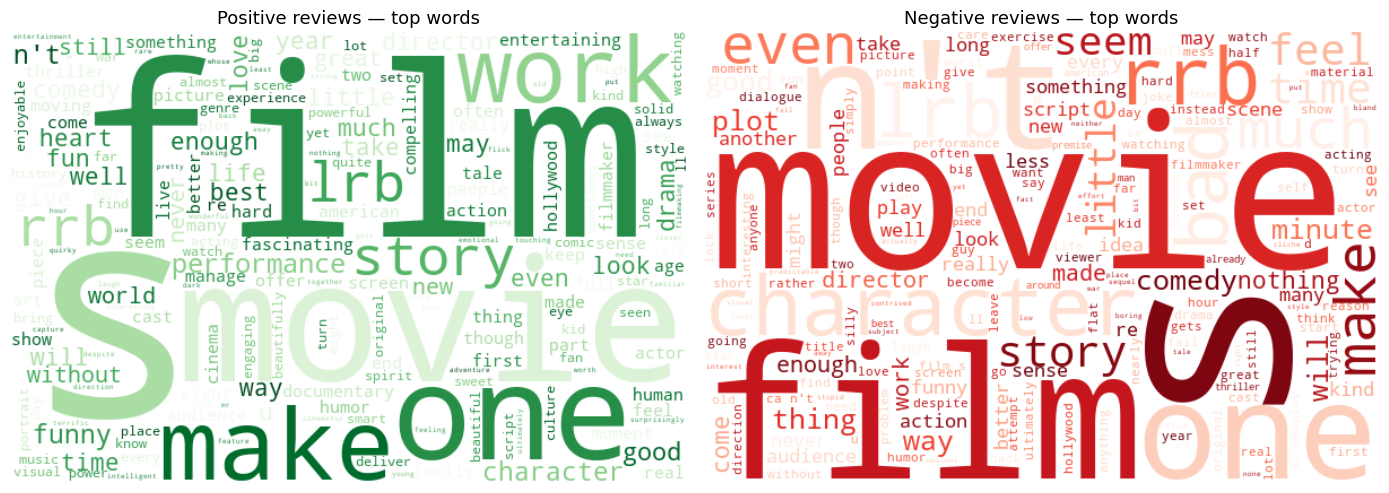

In [4]:
pos_text = ' '.join(df[df['label'] == 1]['text'].tolist())
neg_text = ' '.join(df[df['label'] == 0]['text'].tolist())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

wc_pos = WordCloud(width=600, height=400, background_color='white', 
                   colormap='Greens').generate(pos_text)
ax1.imshow(wc_pos, interpolation='bilinear')
ax1.axis('off')
ax1.set_title('Positive reviews — top words', fontsize=13)

wc_neg = WordCloud(width=600, height=400, background_color='white', 
                   colormap='Reds').generate(neg_text)
ax2.imshow(wc_neg, interpolation='bilinear')
ax2.axis('off')
ax2.set_title('Negative reviews — top words', fontsize=13)

plt.tight_layout()
plt.savefig('chart_wordcloud.png', dpi=150)
plt.show()

## WordCloud observations
- Positive reviews frequently use: performance, compelling, beautiful, heart, best
- Negative reviews frequently use: nothing, bad, flat, silly, despite
- Both share: film, movie, make, one, story — these are noise words to remove in preprocessing
- "lrb/rrb" appears in both clouds — these are likely bracket artifacts in the data to clean

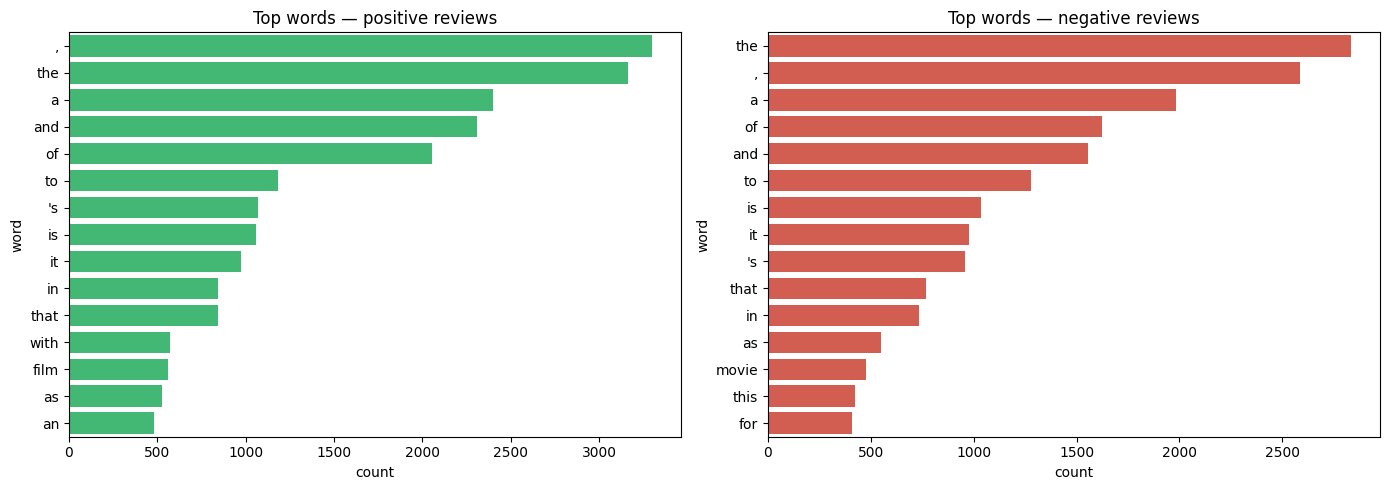

In [5]:
from collections import Counter

def top_words(texts, n=15):
    words = ' '.join(texts).split()
    return pd.DataFrame(Counter(words).most_common(n), columns=['word', 'count'])

pos_words = top_words(df[df['label']==1]['text'])
neg_words = top_words(df[df['label']==0]['text'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=pos_words, x='count', y='word', ax=ax1, color='#2ecc71')
ax1.set_title('Top words — positive reviews')

sns.barplot(data=neg_words, x='count', y='word', ax=ax2, color='#e74c3c')
ax2.set_title('Top words — negative reviews')

plt.tight_layout()
plt.savefig('chart_top_words.png', dpi=150)
plt.show()

/var/folders/xb/blk7kpmd3vj2lvy9kh5w4k_40000gn/T/ipykernel_61332/3816570100.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='length', data=df, palette=['#e74c3c', '#2ecc71'])


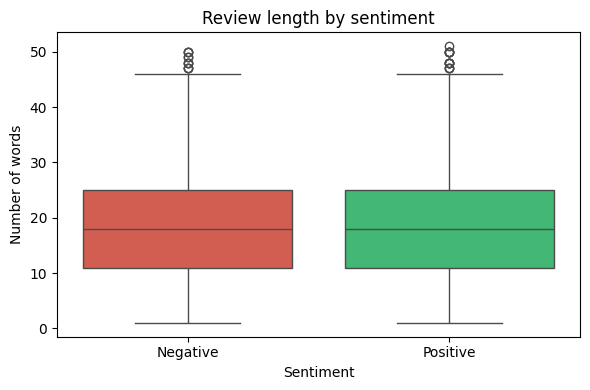

In [6]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='label', y='length', data=df, palette=['#e74c3c', '#2ecc71'])
plt.xticks([0, 1], ['Negative', 'Positive'])
plt.title('Review length by sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Number of words')
plt.tight_layout()
plt.savefig('chart_length_boxplot.png', dpi=150)
plt.show()

## EDA Summary

- **Dataset:** 6920 reviews — 3610 positive, 3310 negative (well balanced)
- **Avg length:** 19 words (short sentence-level reviews)
- **Positive reviews** are slightly longer than negative ones
- **Key signal words:** positive = performance, compelling, beautiful | negative = nothing, bad, flat
- **Noise to clean:** film, movie, one, make, lrb, rrb — will be removed as stopwords in Day 3
- **No nulls or major class imbalance** — data is ready for modelling